Contents of /kaggle/input: ['datasets']

================= FOLDER TREE (image folders) =================

/kaggle/input/datasets/sodko3/lits-dataset-liver-and-tumor-segmentation-256x256/Thesis_data/Images   |  58638 files  {'.png': 58638}
   examples: ['volume-0_0.png', 'volume-0_1.png', 'volume-0_10.png', 'volume-0_11.png', 'volume-0_12.png', 'volume-0_13.png']

/kaggle/input/datasets/sodko3/lits-dataset-liver-and-tumor-segmentation-256x256/Thesis_data/Liver_mask   |  58638 files  {'.png': 58638}
   examples: ['livermask-0_0.png', 'livermask-0_1.png', 'livermask-0_10.png', 'livermask-0_11.png', 'livermask-0_12.png', 'livermask-0_13.png']

/kaggle/input/datasets/sodko3/lits-dataset-liver-and-tumor-segmentation-256x256/Thesis_data/Tumor_mask   |  58638 files  {'.png': 58638}
   examples: ['tumormask-0_0.png', 'tumormask-0_1.png', 'tumormask-0_10.png', 'tumormask-0_11.png', 'tumormask-0_12.png', 'tumormask-0_13.png']

TOTAL image-like files found: 175914

[fallback] token split failed ->

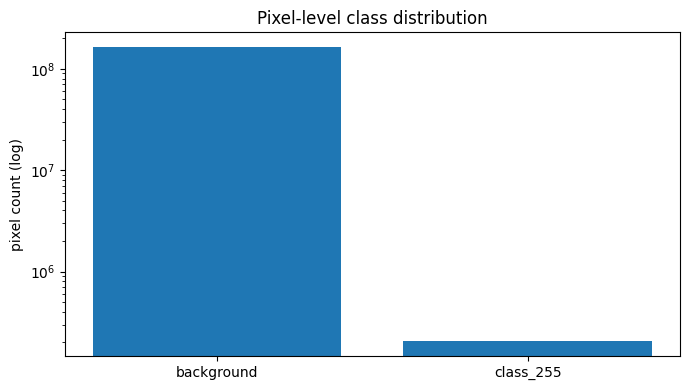

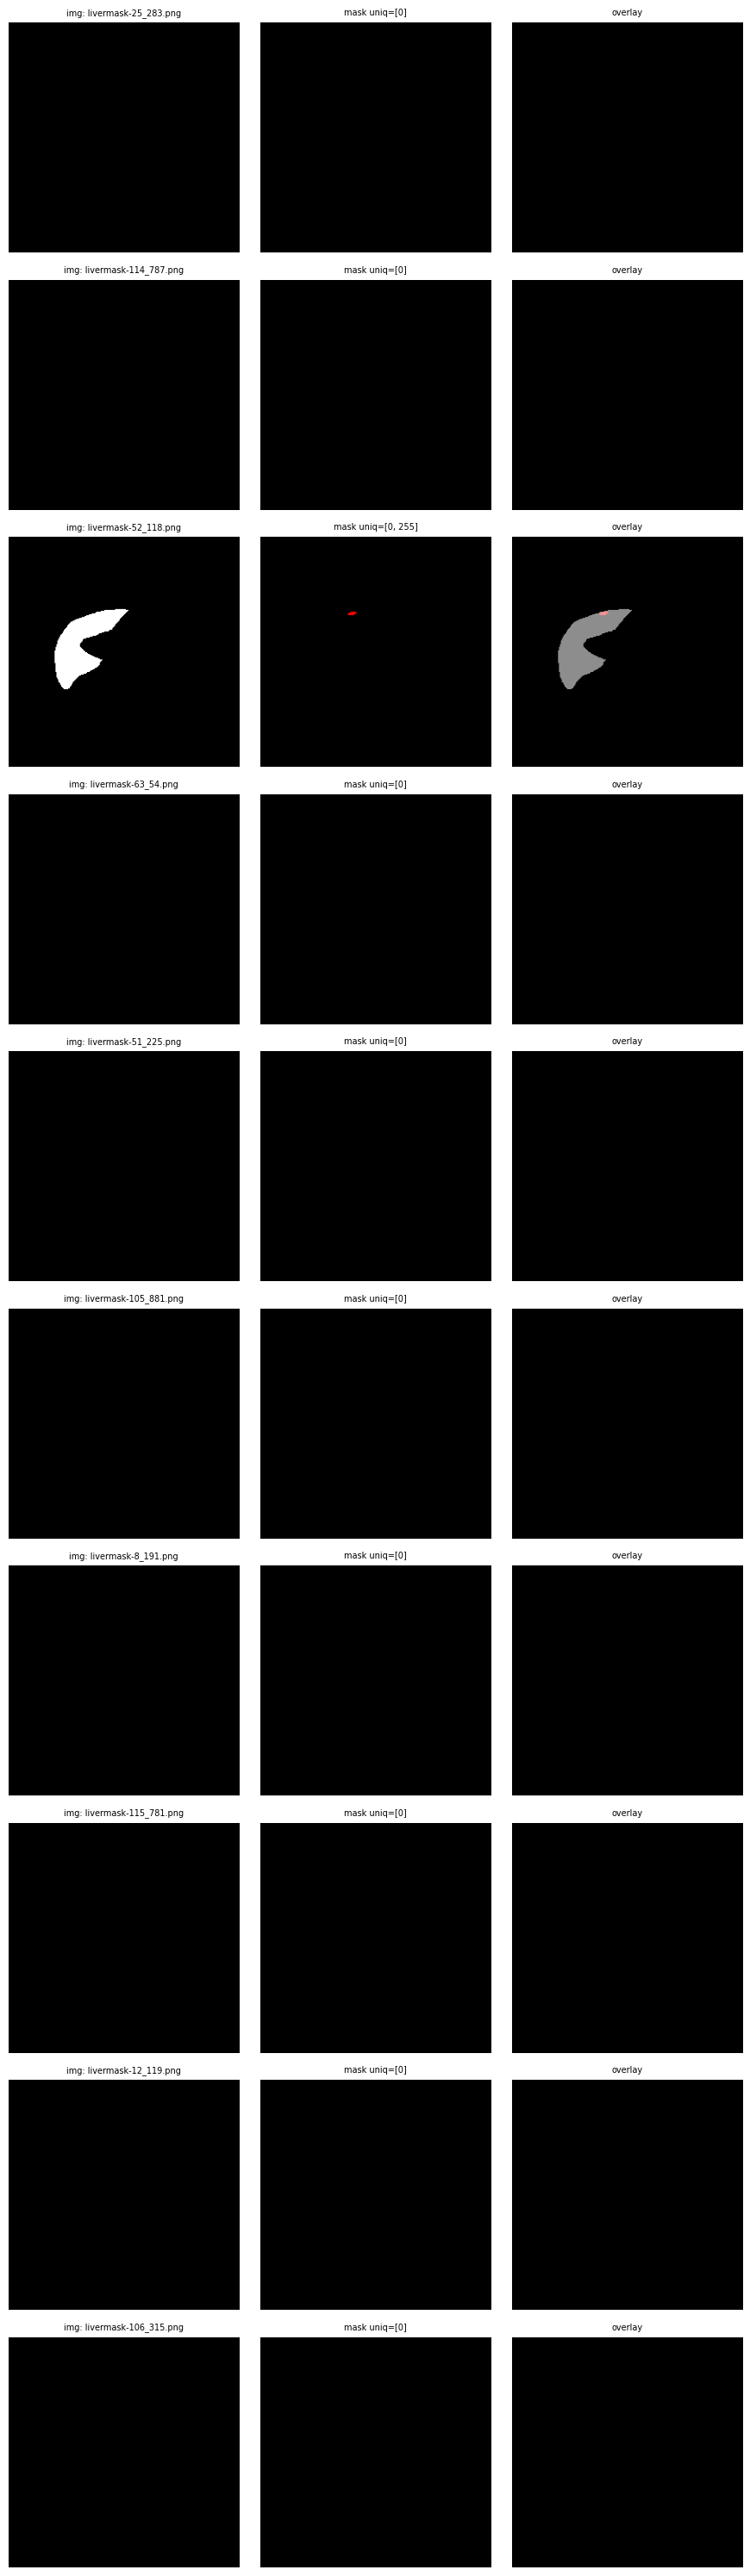



=================== SUMMARY FOR REVIEW (paste to Claude) ===================
input folders           : ['datasets']
total image-like files  : 175914
images / masks / pairs  : 58638 / 58638 / 58638
image example name      : livermask-8_145.png
mask  example name      : tumormask-18_222.png
resolution shapes       : {(256, 256): 400}
mask unique values      : [0, 255]
pixel class distribution:
 value      class    pixels  percent
     0 background 163635528  99.8752
   255  class_255    204472   0.1248
unique volume IDs       : 131
volume-grouped split ok : True


In [1]:
# =====================================================================
# LiTS 256x256 — EDA PROBE  (paste into ONE Kaggle notebook cell & Run)
# Dataset: sodko3/lits-dataset-liver-and-tumor-segmentation-256x256
# =====================================================================
import os, re, random
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
OUT = Path("/kaggle/working"); OUT.mkdir(exist_ok=True, parents=True)

# ---------------------------------------------------------------------
# 1) DISCOVER: walk the mounted dataset and print the folder tree
# ---------------------------------------------------------------------
INPUT_ROOT = Path("/kaggle/input")
print("Contents of /kaggle/input:", [p.name for p in INPUT_ROOT.glob("*")])

files_by_dir = defaultdict(list)
for p in INPUT_ROOT.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMG_EXT:
        files_by_dir[p.parent].append(p)

print("\n================= FOLDER TREE (image folders) =================")
for d in sorted(files_by_dir, key=lambda x: str(x)):
    fs = files_by_dir[d]
    exts = Counter(f.suffix.lower() for f in fs)
    examples = [f.name for f in sorted(fs)[:6]]
    print(f"\n{d}   |  {len(fs)} files  {dict(exts)}")
    print("   examples:", examples)

all_files = [f for fs in files_by_dir.values() for f in fs]
print(f"\nTOTAL image-like files found: {len(all_files)}")

# ---------------------------------------------------------------------
# 2) SPLIT into images vs masks (by folder/name tokens), then PAIR them
# ---------------------------------------------------------------------
MASK_TOK  = ("mask", "label", "seg", "gt", "annot", "ground", "lesion", "liver_tumor")

def is_mask(path):
    s = str(path).lower()
    return any(t in s for t in MASK_TOK)

masks  = [f for f in all_files if is_mask(f)]
images = [f for f in all_files if not is_mask(f)]
if len(masks) == 0 or len(images) == 0:
    dirs = sorted(files_by_dir, key=lambda d: -len(files_by_dir[d]))
    if len(dirs) >= 2:
        images = files_by_dir[dirs[0]]; masks = files_by_dir[dirs[1]]
        print("\n[fallback] token split failed -> using two largest folders as image/mask")

def ints_key(name):
    return tuple(int(x) for x in re.findall(r"\d+", Path(name).stem))

img_by_key  = {ints_key(f): f for f in images}
mask_by_key = {ints_key(f): f for f in masks}
paired_keys = sorted(set(img_by_key) & set(mask_by_key))
pairs = [(img_by_key[k], mask_by_key[k]) for k in paired_keys]

print("\n================= IMAGE / MASK PAIRING =================")
print(f"images: {len(images)} | masks: {len(masks)} | matched pairs: {len(pairs)}")
if images: print("image example:", images[0].name)
if masks:  print("mask  example:", masks[0].name)
if len(pairs) < min(len(images), len(masks)) * 0.9:
    print("!! WARNING: many files did not pair — filename convention may differ.")

# ---------------------------------------------------------------------
# 3) FILENAME -> VOLUME/PATIENT ID  (the leakage-critical question)
# ---------------------------------------------------------------------
def parse_volume_id(name):
    s = Path(name).stem.lower()
    m = re.search(r"(?:volume|segmentation|vol|v)[-_ ]?(\d+)", s)
    if m: return int(m.group(1))
    nums = re.findall(r"\d+", s)
    return int(nums[0]) if nums else None

key_files = images if images else all_files
vol_ids = [parse_volume_id(f.name) for f in key_files]
slices_per_vol = Counter(v for v in vol_ids if v is not None)
print("\n================= VOLUME / PATIENT GROUPING =================")
print("sample filenames:", [f.name for f in sorted(key_files)[:12]])
print(f"unique volume IDs parsed : {len(slices_per_vol)}")
if slices_per_vol:
    spv = np.array(list(slices_per_vol.values()))
    print(f"slices per volume -> min {spv.min()}  median {int(np.median(spv))}  max {spv.max()}")
    print("first 10 (volume_id: #slices):", dict(list(sorted(slices_per_vol.items()))[:10]))
VOLUME_OK = len(slices_per_vol) > 1 and max(slices_per_vol.values()) > 1
print("-> Volume-grouped (leakage-safe) split feasible:", VOLUME_OK)

# ---------------------------------------------------------------------
# 4) RESOLUTION uniformity  (sample up to 400 images)
# ---------------------------------------------------------------------
def load_arr(path):
    return np.array(Image.open(path))

shape_counter = Counter()
for f in random.sample(images or all_files, min(400, len(images or all_files))):
    try: shape_counter[load_arr(f).shape] += 1
    except Exception as e: print("corrupt?", f.name, e)
print("\n================= RESOLUTION =================")
for shp, c in shape_counter.most_common():
    print(f"  shape {shp}: {c} files")

# ---------------------------------------------------------------------
# 5) MASK ENCODING + PIXEL-LEVEL CLASS DISTRIBUTION
# ---------------------------------------------------------------------
mask_sample = random.sample(masks, min(2500, len(masks))) if masks else []
hist = np.zeros(256, dtype=np.int64)
uniq_seen = set(); n_used = 0
for mp in mask_sample:
    try:
        m = load_arr(mp)
        if m.ndim == 3: m = m[..., 0]
        vals, counts = np.unique(m, return_counts=True)
        hist[vals.astype(int)] += counts
        uniq_seen.update(vals.tolist()); n_used += 1
    except Exception as e:
        print("mask read error:", mp.name, e)

print("\n================= MASK ENCODING =================")
print(f"masks scanned: {n_used}")
print("unique pixel values across masks:", sorted(uniq_seen))
CLASS_NAMES = {0: "background", 1: "liver", 2: "tumor"}
total_px = hist.sum()
print("\n--- PIXEL-LEVEL CLASS DISTRIBUTION ---")
rows = []
for v in sorted(uniq_seen):
    pct = 100.0 * hist[v] / total_px if total_px else 0
    rows.append({"value": v, "class": CLASS_NAMES.get(v, f"class_{v}"),
                 "pixels": int(hist[v]), "percent": round(pct, 4)})
dist_df = pd.DataFrame(rows)
print(dist_df.to_string(index=False))
if 2 in uniq_seen:
    print(f"\n-> tumor (class 2) share = {100*hist[2]/total_px:.4f}%")

plt.figure(figsize=(7,4))
plt.bar(dist_df["class"], dist_df["pixels"].clip(lower=1))
plt.yscale("log"); plt.ylabel("pixel count (log)"); plt.title("Pixel-level class distribution")
plt.tight_layout(); plt.savefig(OUT/"eda_class_distribution.png", dpi=110); plt.show()

# ---------------------------------------------------------------------
# 6) VISUALISE 10 image/mask pairs (prefer some containing tumor)
# ---------------------------------------------------------------------
def has_tumor(mp):
    try:
        m = load_arr(mp); m = m[...,0] if m.ndim==3 else m
        return 2 in np.unique(m)
    except Exception: return False

if pairs:
    tumor_pairs = [p for p in random.sample(pairs, min(len(pairs), 300)) if has_tumor(p[1])]
    chosen = (tumor_pairs[:5] + random.sample(pairs, 10))[:10]
    cmap = plt.matplotlib.colors.ListedColormap(["black", "yellow", "red"])
    fig, ax = plt.subplots(len(chosen), 3, figsize=(9, 3*len(chosen)))
    for i, (ip, mp) in enumerate(chosen):
        img = load_arr(ip); msk = load_arr(mp); msk = msk[...,0] if msk.ndim==3 else msk
        ax[i,0].imshow(img, cmap="gray"); ax[i,0].set_title(f"img: {ip.name}", fontsize=7)
        ax[i,1].imshow(msk, cmap=cmap, vmin=0, vmax=2); ax[i,1].set_title(f"mask uniq={sorted(np.unique(msk).tolist())}", fontsize=7)
        ax[i,2].imshow(img, cmap="gray"); ax[i,2].imshow(msk, cmap=cmap, vmin=0, vmax=2, alpha=0.45)
        ax[i,2].set_title("overlay", fontsize=7)
        for j in range(3): ax[i,j].axis("off")
    plt.tight_layout(); plt.savefig(OUT/"eda_samples.png", dpi=110); plt.show()
else:
    print("No pairs to visualise — fix the image/mask detection first.")

# ---------------------------------------------------------------------
# 7) SUMMARY FOR REVIEW  (copy this whole block and send to Claude)
# ---------------------------------------------------------------------
print("\n\n=================== SUMMARY FOR REVIEW (paste to Claude) ===================")
print(f"input folders           : {[p.name for p in INPUT_ROOT.glob('*')]}")
print(f"total image-like files  : {len(all_files)}")
print(f"images / masks / pairs  : {len(images)} / {len(masks)} / {len(pairs)}")
print(f"image example name      : {images[0].name if images else 'NA'}")
print(f"mask  example name      : {masks[0].name if masks else 'NA'}")
print(f"resolution shapes       : {dict(shape_counter)}")
print(f"mask unique values      : {sorted(uniq_seen)}")
print("pixel class distribution:"); print(dist_df.to_string(index=False))
print(f"unique volume IDs       : {len(slices_per_vol)}")
print(f"volume-grouped split ok : {VOLUME_OK}")
print("===========================================================================")
